HOLLOW KNIGHT ACHIEVEMENT ANALYSIS
Hypothesis: The biggest player drop-off would initially be at the beginning of the game, even before the player receives their first achievement; Hollow Knight is a unique and mechanically difficult game, yet the lack of direction would be the main driving force leading to an early abandoment before the player's skill issue becomes a factor, a second drop-off will occur later, around major skill checks, such as Mantis Lords or Soul Master

DATA SOURCE: Steam's Global Achievement API, pulled from live Hollow Knight achievements statistics (ID: 367520)

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://api.steampowered.com/ISteamUserStats/GetGlobalAchievementPercentagesForApp/v2/?gameid=367520"
response = requests.get(url)
data = response.json()
print(data)

{'achievementpercentages': {'achievements': [{'name': 'CHARMED', 'percent': '77.1'}, {'name': 'FK_DEFEAT', 'percent': '71.6'}, {'name': 'HORNET_1', 'percent': '63.0'}, {'name': 'STAG_STATION_HALF', 'percent': '49.2'}, {'name': 'PROTECTED', 'percent': '47.9'}, {'name': 'SOUL_MASTER_DEFEAT', 'percent': '47.1'}, {'name': 'MANTIS_LORDS', 'percent': '46.6'}, {'name': 'SOULFUL', 'percent': '43.8'}, {'name': 'DUNG_DEFENDER', 'percent': '42.8'}, {'name': 'BROKEN_VESSEL', 'percent': '41.9'}, {'name': 'ENCHANTED', 'percent': '39.9'}, {'name': 'BEAST', 'percent': '38.8'}, {'name': 'HORNET_2', 'percent': '38.6'}, {'name': 'GRUBFRIEND', 'percent': '38.4'}, {'name': 'ATTUNEMENT', 'percent': '38.1'}, {'name': 'TEACHER', 'percent': '37.7'}, {'name': 'COLOSSEUM_1', 'percent': '37.6'}, {'name': 'WATCHER', 'percent': '37.5'}, {'name': 'MAP', 'percent': '36.4'}, {'name': 'COLOSSEUM_2', 'percent': '34.4'}, {'name': 'TRAITOR_LORD', 'percent': '33.2'}, {'name': 'STAG_STATION_ALL', 'percent': '33.0'}, {'name'

In [3]:
achievements = data['achievementpercentages']['achievements']
df = pd.DataFrame(achievements)
df['percent'] = df['percent'].astype(float)
print(df)

                    name  percent
0                CHARMED     77.1
1              FK_DEFEAT     71.6
2               HORNET_1     63.0
3      STAG_STATION_HALF     49.2
4              PROTECTED     47.9
..                   ...      ...
58      SPEED_COMPLETION      5.3
59               ENDINGD      5.2
60            SPEEDRUN_2      5.2
61             STEELSOUL      4.5
62  STEELSOUL_COMPLETION      3.8

[63 rows x 2 columns]


In [6]:
pd.set_option('display.max_rows', None)
print(df)

                        name  percent
0                    CHARMED     77.1
1                  FK_DEFEAT     71.6
2                   HORNET_1     63.0
3          STAG_STATION_HALF     49.2
4                  PROTECTED     47.9
5         SOUL_MASTER_DEFEAT     47.1
6               MANTIS_LORDS     46.6
7                    SOULFUL     43.8
8              DUNG_DEFENDER     42.8
9              BROKEN_VESSEL     41.9
10                 ENCHANTED     39.9
11                     BEAST     38.8
12                  HORNET_2     38.6
13                GRUBFRIEND     38.4
14                ATTUNEMENT     38.1
15                   TEACHER     37.7
16               COLOSSEUM_1     37.6
17                   WATCHER     37.5
18                       MAP     36.4
19               COLOSSEUM_2     34.4
20              TRAITOR_LORD     33.2
21          STAG_STATION_ALL     33.0
22                 COLLECTOR     31.0
23       DREAM_BROKEN_VESSEL     30.5
24                 AWAKENING     30.1
25          

In [12]:
achievement_names = {
    'CHARMED': 'First Charm Acquired (Collectible)',
    'FK_DEFEAT': 'Boss: False Knight (First Boss)',
    'HORNET_1': 'Boss: Hornet 1 (Early Game)',
    'STAG_STATION_HALF': 'Half of Fast Travel Unlocked',
    'PROTECTED': 'Collected 4 Mask Shards (Health Upgrades)',
    'SOUL_MASTER_DEFEAT': 'Boss: Soul Master (Mid Game)',
    'MANTIS_LORDS': 'Boss: Mantis Lords (Mid Game Skill Check)',
    'SOULFUL': 'Collected 3 Vessel Fragments (Mana Upgrades)',
    'DUNG_DEFENDER': 'Boss: Dung Defender (Mid Game)',
    'BROKEN_VESSEL': 'Boss: Broken Vessel (Mid Game)',
    'ENCHANTED': 'Half of All Charms Collected',
    'BEAST': 'Dreamer: Herrah the Beast (Required for Ending)',
    'HORNET_2': 'Boss: Hornet 2 (Late Game)',
    'GRUBFRIEND': 'Rescued Half of All Grubs (Collectible)',
    'ATTUNEMENT': 'Dream Nail - 600 Essence Collected',
    'TEACHER': 'Dreamer: Monomon the Teacher (Required for Ending)',
    'COLOSSEUM_1': 'Colosseum: Trial of the Warrior (Optional)',
    'WATCHER': 'Dreamer: Lurien the Watcher (Required for Ending)',
    'MAP': 'Acquired First Map',
    'COLOSSEUM_2': 'Colosseum: Trial of the Conqueror (Optional)',
    'TRAITOR_LORD': 'Boss: Traitor Lord (Optional Late Game)',
    'STAG_STATION_ALL': 'All Fast Travel Unlocked',
    'COLLECTOR': 'Boss: The Collector (Optional)',
    'DREAM_BROKEN_VESSEL': 'Boss: Lost Kin (Dream Boss Optional)',
    'AWAKENING': 'Dream Nail - 1800 Essence Collected',
    'ZOTE': 'Boss: Zote the Mighty (Optional Colosseum)',
    'GRIMM': 'Boss: Troupe Master Grimm (DLC)',
    'DREAM_FK': 'Boss: Failed Champion (Dream Boss Optional)',
    'METAMORPHOSIS': 'Rescued All Grubs (Collectible)',
    'VOID': 'Void Heart Obtained (Unlocks True Ending)',
    'WORLDSOUL': 'All Vessel Fragments Collected (Max Mana)',
    'QUIRREL_EPILOGUE': 'NPC: Final Moment with Quirrel',
    'ENDING_A': 'Ending: The Hollow Knight (Basic Ending)',
    'DREAM_SOUL_MASTER_DEFEAT': 'Boss: Soul Tyrant (Dream Boss Optional)',
    'GREY_PRINCE': 'Boss: Grey Prince Zote (Optional)',
    'MOURNER': 'Quest: Grey Mourner Completed',
    'COLOSSEUM_3': 'Colosseum: Trial of the Fool (Hardest Optional)',
    'ENDING_C': 'Ending: Dream No More (True Ending)',
    'ASCENSION': 'Dream Nail - 2400 Essence (Max)',
    'MASKED': 'All Mask Shards Collected (Max Health)',
    'BLESSED': 'All Charms Collected',
    'COMPLETION': '100% Game Completion',
    'ENDING_B': 'Ending: Sealed Siblings',
    'WHITE_DEFENDER': 'Boss: White Defender (Dream Boss Optional)',
    'NAILSMITH_KILL': 'Quest: Killed the Nailsmith',
    'PANTHEON1': 'Godmaster DLC: Pantheon 1 of 5',
    'PANTHEON2': 'Godmaster DLC: Pantheon 2 of 5',
    'NIGHTMARE_GRIMM': 'Boss: Nightmare King Grimm (DLC Hard)',
    'PANTHEON3': 'Godmaster DLC: Pantheon 3 of 5',
    'NAILSMITH_SPARE': 'Quest: Spared the Nailsmith',
    'PANTHEON4': 'Godmaster DLC: Pantheon 4 of 5',
    'BANISHMENT': 'DLC: Grimm Troupe Banished (Alternate Path)',
    'HUNTER_1': 'Hunter Journal Half Complete',
    'NEGLECT': 'Let Zote Die (Optional Choice)',
    'HUNTER_2': 'Hunter Journal Fully Complete',
    'COMPLETIONGG': '112% Game Completion (All DLC)',
    'MR_MUSHROOM': 'Secret Quest: Mr Mushroom Completed',
    'SPEEDRUN_1': 'Speed Run: Under 10 Hours',
    'SPEED_COMPLETION': 'Speed Run: 100% Under 20 Hours',
    'ENDINGD': 'Ending: Embrace the Void (DLC Ending)',
    'SPEEDRUN_2': 'Speed Run: Under 5 Hours',
    'STEELSOUL': 'Steel Soul Mode Completed (No Deaths)',
    'STEELSOUL_COMPLETION': 'Steel Soul 112% (No Deaths, All Content)'
}

df['readable_name'] = df['name'].map(achievement_names)
print(df)

                        name  percent  \
0                    CHARMED     77.1   
1                  FK_DEFEAT     71.6   
2                   HORNET_1     63.0   
3          STAG_STATION_HALF     49.2   
4                  PROTECTED     47.9   
5         SOUL_MASTER_DEFEAT     47.1   
6               MANTIS_LORDS     46.6   
7                    SOULFUL     43.8   
8              DUNG_DEFENDER     42.8   
9              BROKEN_VESSEL     41.9   
10                 ENCHANTED     39.9   
11                     BEAST     38.8   
12                  HORNET_2     38.6   
13                GRUBFRIEND     38.4   
14                ATTUNEMENT     38.1   
15                   TEACHER     37.7   
16               COLOSSEUM_1     37.6   
17                   WATCHER     37.5   
18                       MAP     36.4   
19               COLOSSEUM_2     34.4   
20              TRAITOR_LORD     33.2   
21          STAG_STATION_ALL     33.0   
22                 COLLECTOR     31.0   
23       DREAM_B

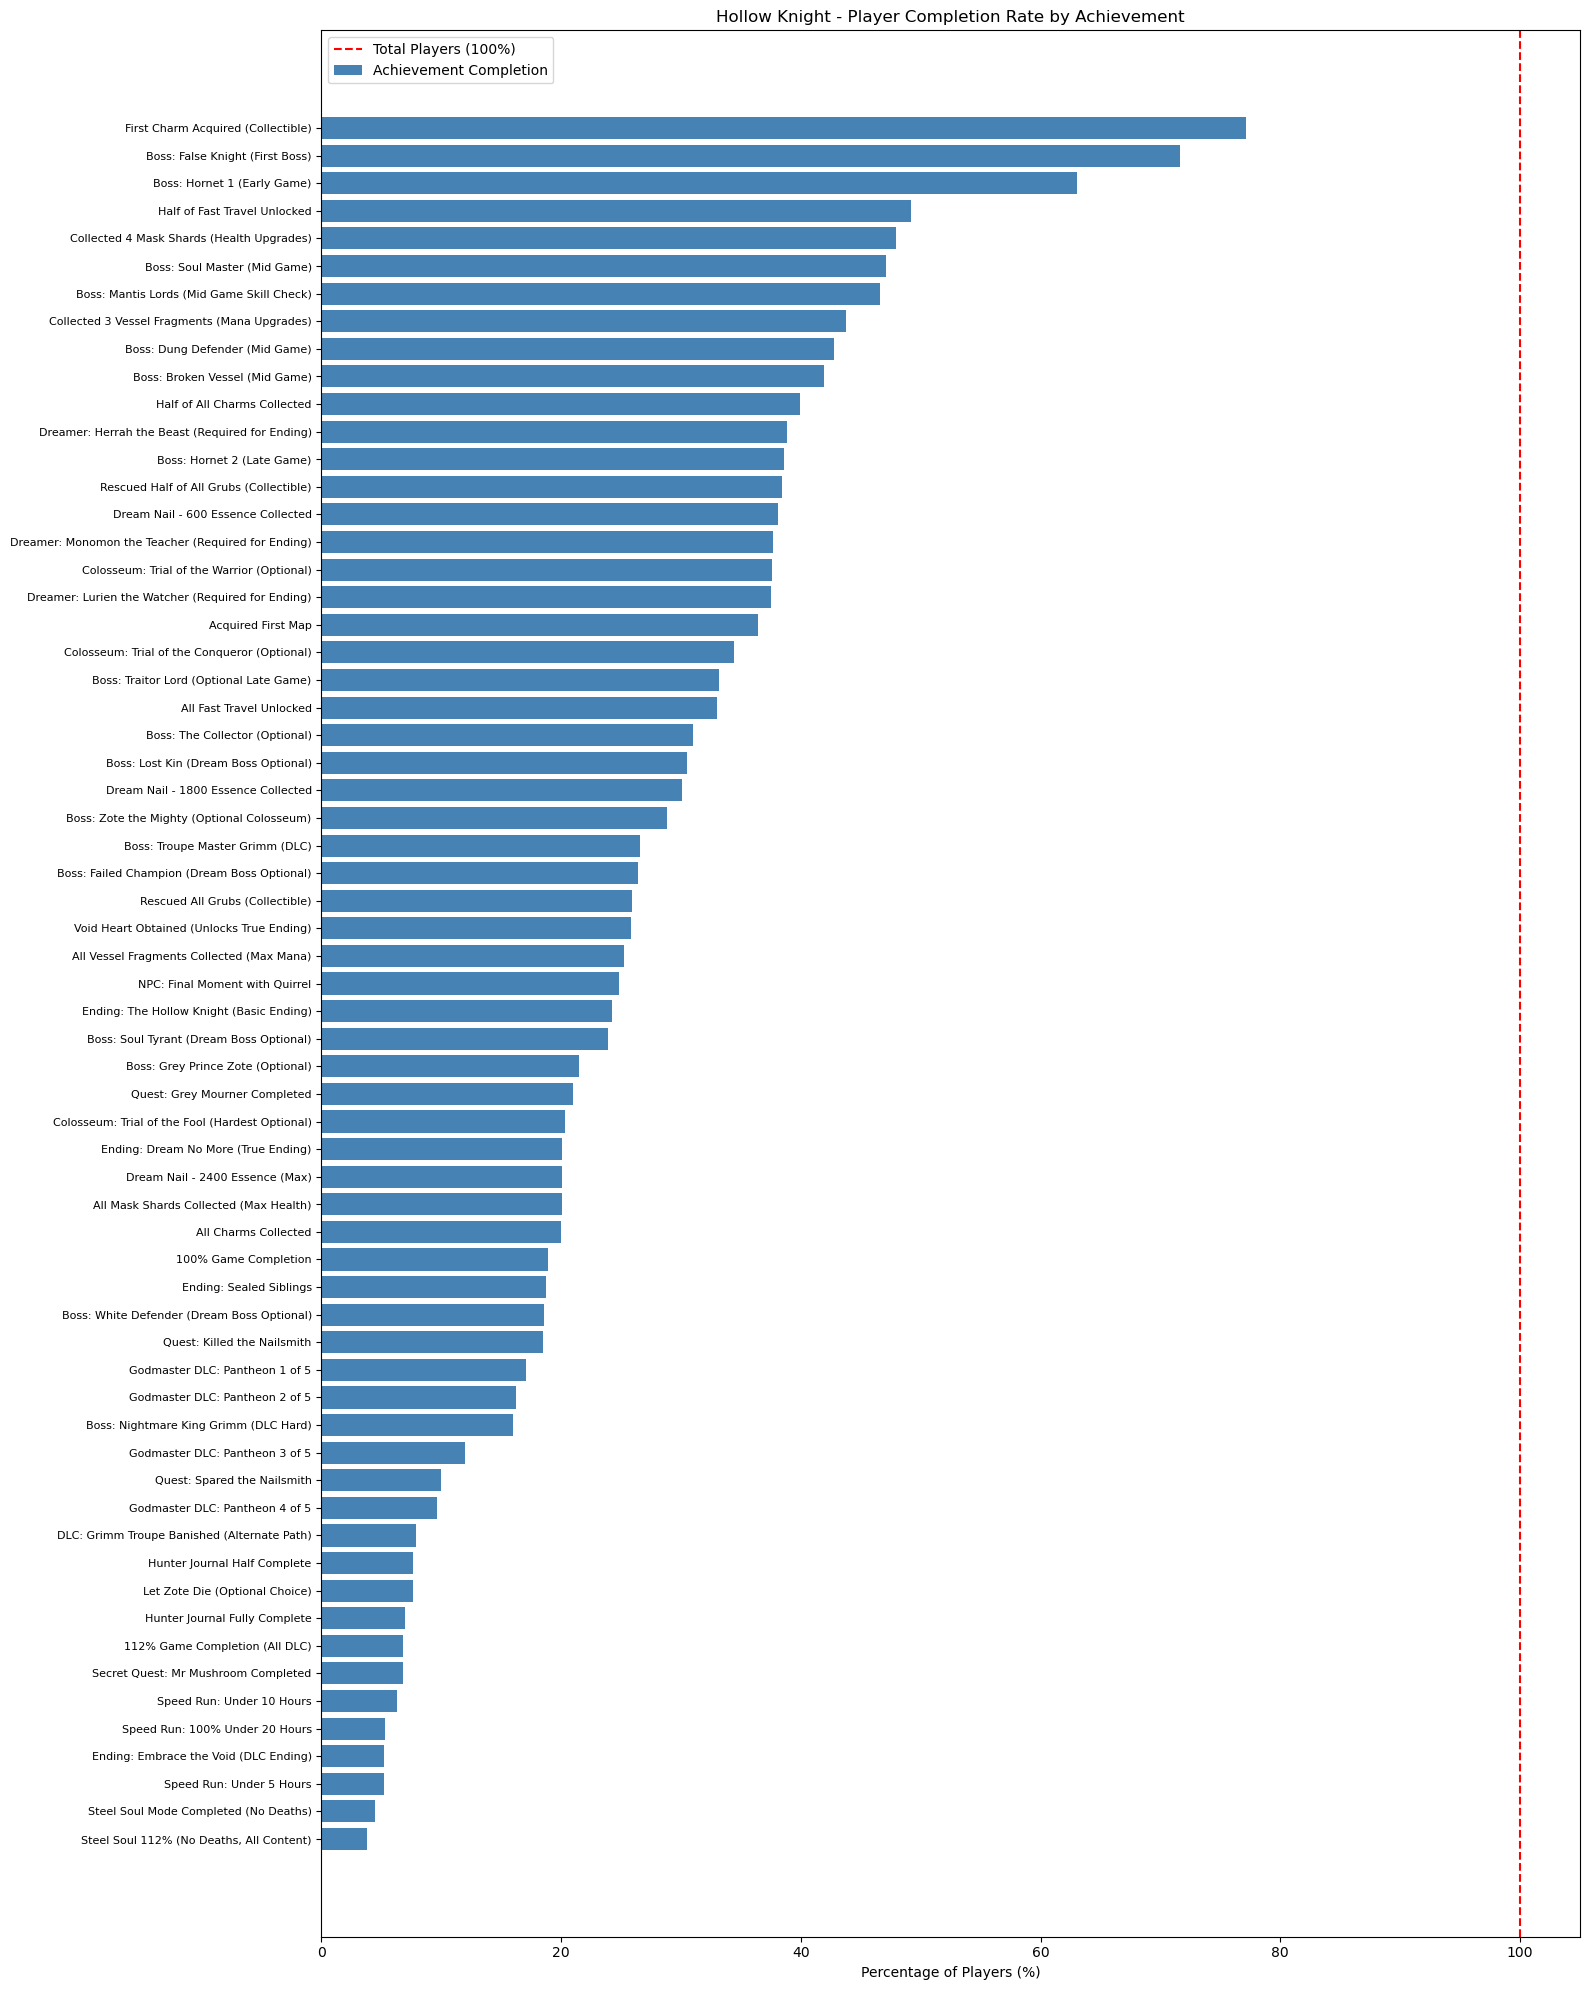

In [19]:
plt.figure(figsize=(16, 20))
plt.axvline(x=100, color='red', linestyle='--', linewidth=1.5, label='Total Players (100%)')
plt.barh(df['readable_name'], df['percent'], color='steelblue', label='Achievement Completion')
plt.xlabel('Percentage of Players (%)')
plt.title('Hollow Knight - Player Completion Rate by Achievement')
plt.xticks(fontsize=10)
plt.yticks(fontsize=8)
plt.legend(fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('completion_chart.png', dpi=150, bbox_inches='tight')
plt.show()

KEY OBSERVATIONS
1. At the beginning, there was already a 30% dropoff of people who purchased and played the game once but never got to the first achievement. You can find the first charm in about 10 minutes of playing the game, so those 30% of individuals were lost even before the game began. This supports the core hypothesis that the early abandonment isn't driven by mechanical difficulty, but rather by the little direction Team Cherry (the developers) implemented, which could be fixed while still keeping the melancholy of the metroidvania genre by adding a basic map so players at least know where they need to go.
2. The player dropoff isn't a steady slope down; players decide to leave in waves. There is a huge wave between the first hornet boss and finding half of the fast travel. After beating mantis lords and getting 3 mana upgrades, it stayed very stable for a while, but started dropping aquiring the first map, which is really interesting. These players somehow played most of the game without even finding a map? That is very interesting, and I could only deduce it from the speedrunning community or from the achievement being bugged by acquiring ONLY the first map in the first area of the game from the map vendor; further investigation would be needed to confirm this, as it's my personal theory. Then it's a steady decline until the DLC, where most players either don't make it or only earn one or two of the DLC achievements. This suggests players quit in clusters after finishing natural content milestones, not at random. The game loses people in waves, not all at once.
3.  The first wave hits quickly. From the first charm at 77% to False Knight at 71% to Hornet 1 at 63%, around 14% of remaining players quit before even reaching the middle of the game. This correlates with the hypothesis that the confusion and lack of direction cause players to abandon early.
4.  Mantis Lords and Soul Master sit right where the second predicted dropoff was expected, around 46 to 47%. Players who pushed through the early confusion still decided to drop it at the first real mechanical skill checks.
5.  The Pantheons Filter Almost Everyone Out (Boss Rush Modes, known for being exceptionally difficult); Pantheon 3 is where it really goes downhill. By Pantheon 4, you're below 10%. Steel Soul sits at 4%. The gap between the average player and the hardcore players is enormous

CONCLUSION: 
    Going into this investigation, my question was relatively simple: Where do most players quit early? I decided from my own experiences that it would be from the initial beginning of the game; I've tried to get into Hollow Knight 3 separate times, and the only time I fully went through with it was getting help from a guide, so using that, my hypothesis assumed that others went through the same confusion I went through, so that most players quit early not because the game is too hard, but because Hollow Knight gives you almost nothing in terms of direction. That turned out to be correct! But the data told a more interesting story than expected.
    The first 30% who never got a single achievement was the first expected surprise, I thought it would've been lower, but it seems that most players couldn't play the game for more than 10 minutes to find the first single collectable. They weren't stopped by a hard boss but by Team Cherry's lackluster directional mapping, which some players praise for its non-handholding approach, while others just become lost. For a significant chunk of players, that was enough to make them close the game and never come back.
What nobody predicted was the wave pattern. Players do not quit in steady lines or uniformly; they quit in clusters. Push through a section, lose a group, repeat. That pattern appears across the entire completion curve and aligns with natural content achievements in the game.
    The map observation was the most unexpected finding. A good portion of players somehow progressed deep into the game without ever picking up the first map, which either points to the speedrunning community skewing the data or a quirk in how the achievement triggers. That alone would be worth investigating further with individual player data, as if 30% of people left because of having no map, I don't understand why a good group of players would purposely subject themselves to going through Hallownest with no direction at all!
    Mantis Lords and Soul Master landed exactly where predicted for the second drop-off. And the Pantheons filtered out almost everyone; only about 4% of players ever reached Steel Soul. The gap between a casual player and a hardcore one is mostly just masochism, as Pantheon 5 is known to take over 20 hours just to complete.
    The biggest takeaway is that Hollow Knight does not lose most of its players to difficulty; it loses them to the game's feelings of loss and emptiness, which are among the main things that make Hollow Knight, Hollow Knight.

LIMITATIONS:
    The data used in this analysis comes from Steam's Global Achievement API, which is free to access for everyone. Sadly, it only gives population-level percentages, not individual player data (which we might cover in the next project, coming soon to a town near you). This means the correlations drawn here are mostly educated guesses rather than fully confirmed. For example, the theory that the path of pain completion predicts Pantheon 5 cannot be confirmed without stalking individual players.
    The 30% abandonment figure is slightly inflated; Steam counts everyone who owns the game, including people who added it to their backlog and bought it on sale but never launched it. The abandonment rate is likely lower.
    The map achievement theory is still unconfirmed and would need individual player data or direct contact with Team Cherry, which I would be glad to do; they seem like awesome people.
    Finally, thanks for reading my project. I had a lot of fun making it! This actually seems like a great career path.

WHAT'S NEXT?
    This project only scratches the surface. The biggest question still is whether players who voluntarily do the difficult optional milestones, like Path of Pain (Difficult Parkour Trial) or Trial of the Fool (Difficult Enemy Rush), are the same ones who end up finishing Pantheon 5. I would believe so, but the data here can't confirm it.
Some questions I actually want to answer in a follow-up:
1. Does finishing Path of Pain or Trial of the Fool predict Pantheon 5 completion, or is it just a coincidence that masochistic players do all the hard content?
2. What percentage of players who start the Pantheons actually finish all five, or do most people decide to keep their sanity?
3. Do players who touch DLC content early tend to finish the base game at higher rates than those who ignore it?
4. Can you build a profile of what a Pantheon 5 player looks like based on their early achievements alone?
    Getting there would require individual player data, which means either scraping public Steam profiles or using an existing Kaggle dataset before building anything from scratch. That's the next project, and honestly, it sounds more fun than this one was.
    

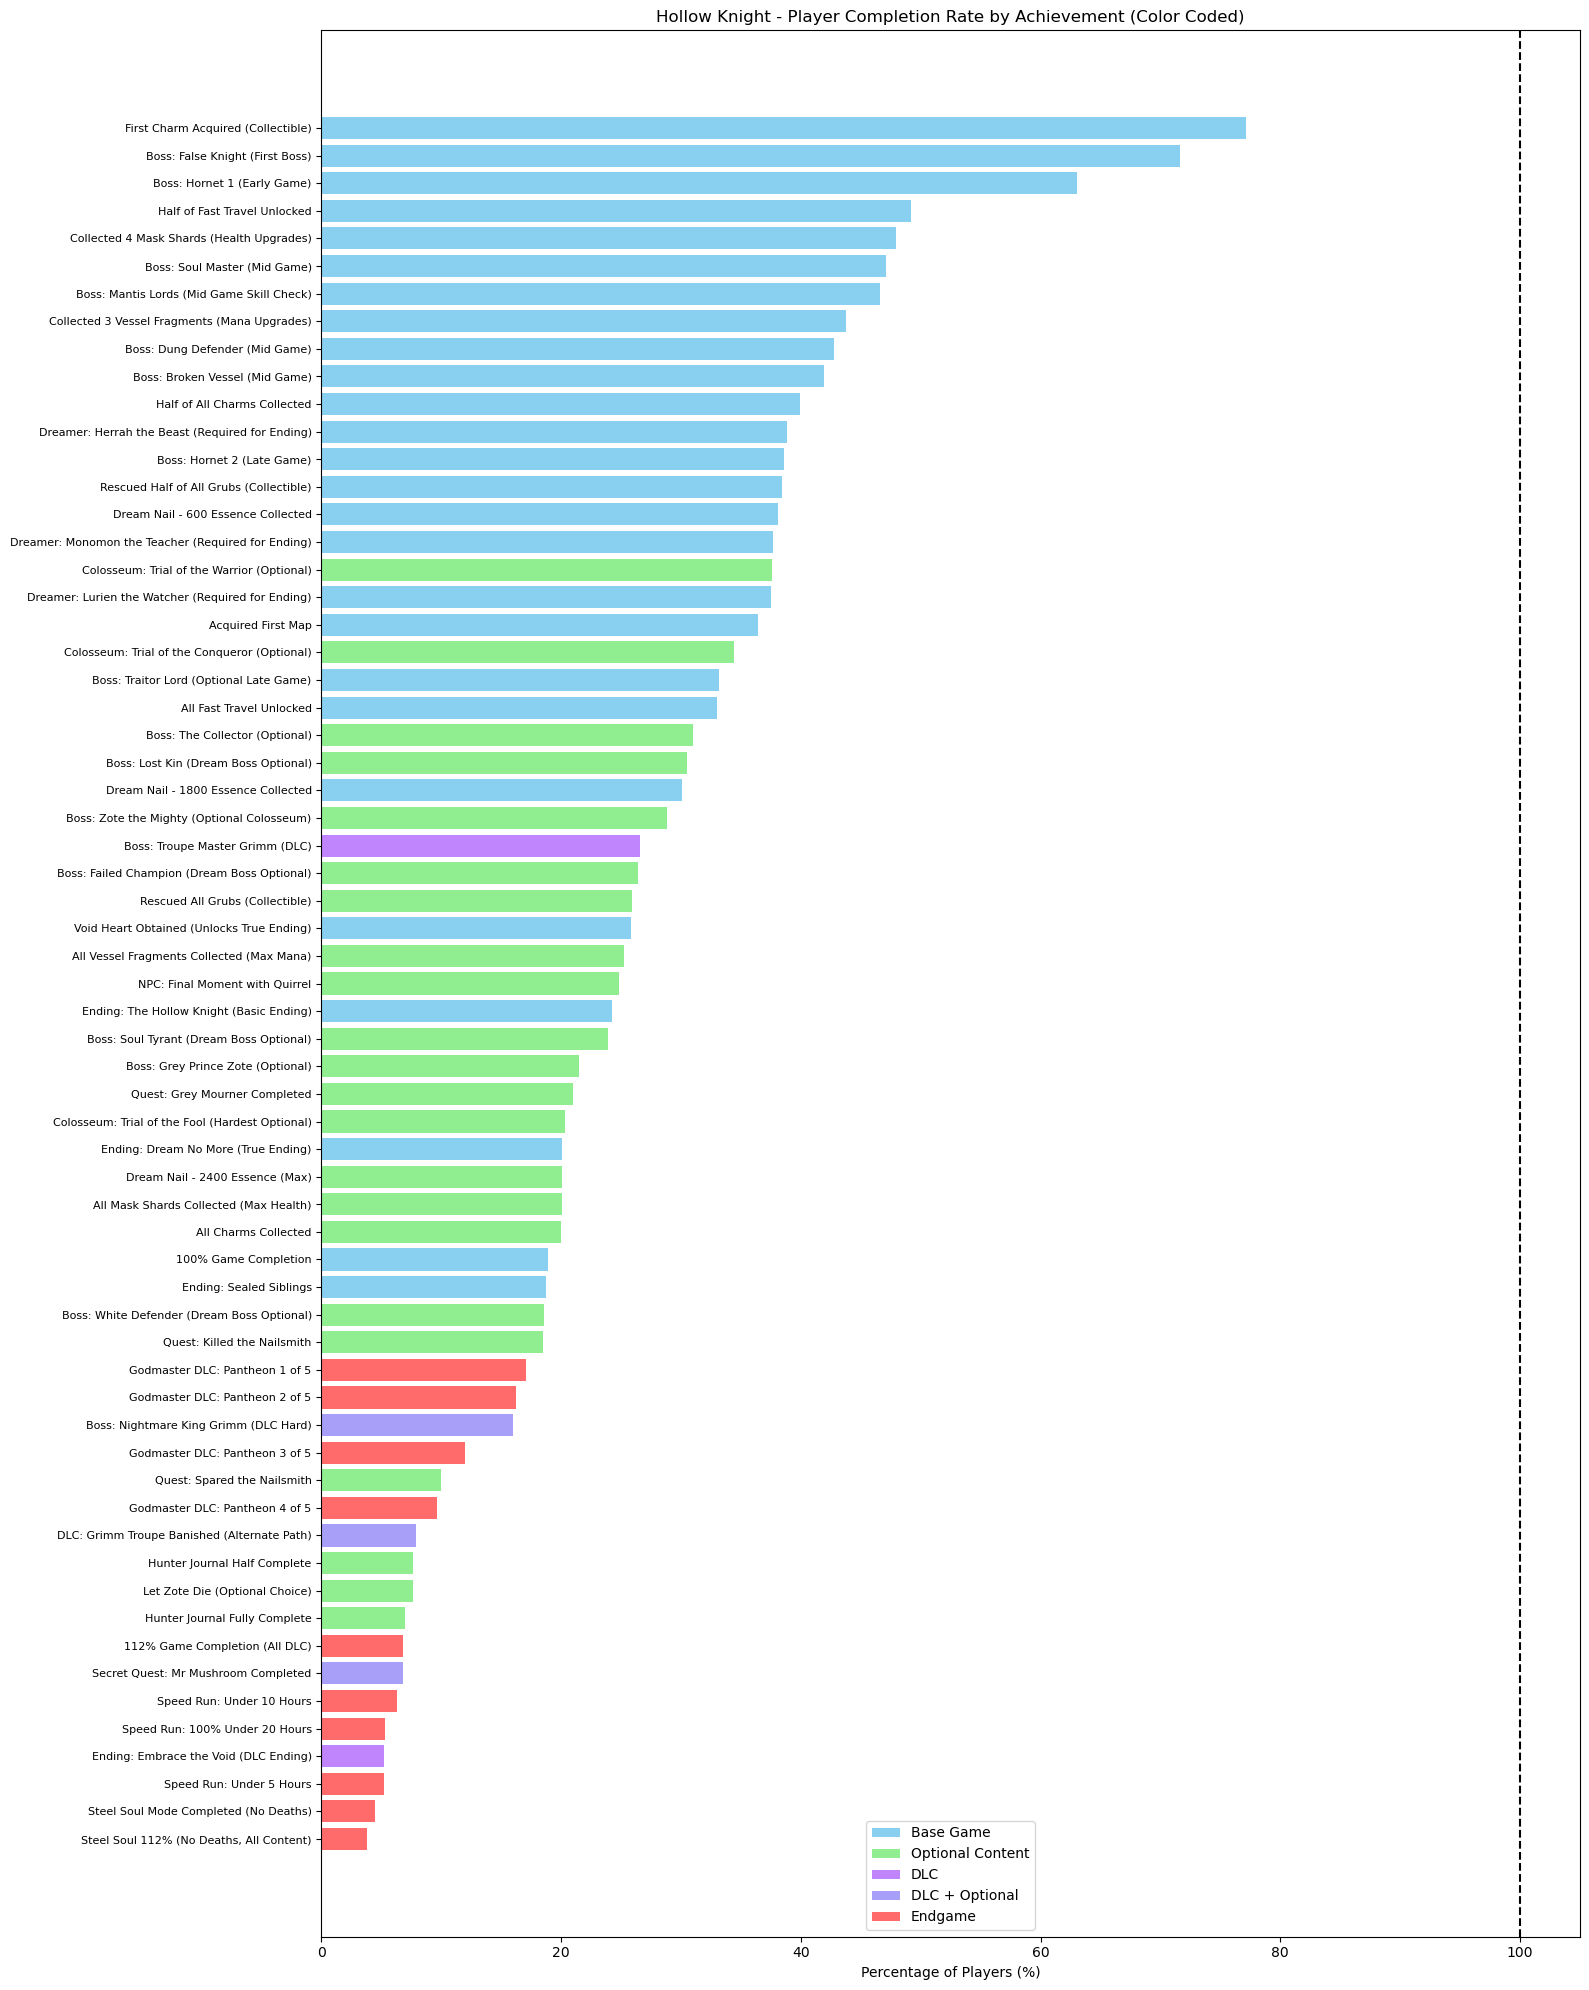

In [20]:
#fun graph, Blue = Base game stuff, green = optional stuff, purple = dlc, red = endgame
achievement_categories = {
    'CHARMED': 'base',
    'FK_DEFEAT': 'base',
    'HORNET_1': 'base',
    'STAG_STATION_HALF': 'base',
    'PROTECTED': 'base',
    'SOUL_MASTER_DEFEAT': 'base',
    'MANTIS_LORDS': 'base',
    'SOULFUL': 'base',
    'DUNG_DEFENDER': 'base',
    'BROKEN_VESSEL': 'base',
    'ENCHANTED': 'base',
    'BEAST': 'base',
    'HORNET_2': 'base',
    'GRUBFRIEND': 'base',
    'ATTUNEMENT': 'base',
    'TEACHER': 'base',
    'COLOSSEUM_1': 'optional',
    'WATCHER': 'base',
    'MAP': 'base',
    'COLOSSEUM_2': 'optional',
    'TRAITOR_LORD': 'base',
    'STAG_STATION_ALL': 'base',
    'COLLECTOR': 'optional',
    'DREAM_BROKEN_VESSEL': 'optional',
    'AWAKENING': 'base',
    'ZOTE': 'optional',
    'GRIMM': 'dlc',
    'DREAM_FK': 'optional',
    'METAMORPHOSIS': 'optional',
    'VOID': 'base',
    'WORLDSOUL': 'optional',
    'QUIRREL_EPILOGUE': 'optional',
    'ENDING_A': 'base',
    'DREAM_SOUL_MASTER_DEFEAT': 'optional',
    'GREY_PRINCE': 'optional',
    'MOURNER': 'optional',
    'COLOSSEUM_3': 'optional',
    'ENDING_C': 'base',
    'ASCENSION': 'optional',
    'MASKED': 'optional',
    'BLESSED': 'optional',
    'COMPLETION': 'base',
    'ENDING_B': 'base',
    'WHITE_DEFENDER': 'optional',
    'NAILSMITH_KILL': 'optional',
    'PANTHEON1': 'endgame',
    'PANTHEON2': 'endgame',
    'NIGHTMARE_GRIMM': 'dlc_optional',
    'PANTHEON3': 'endgame',
    'NAILSMITH_SPARE': 'optional',
    'PANTHEON4': 'endgame',
    'BANISHMENT': 'dlc_optional',
    'HUNTER_1': 'optional',
    'NEGLECT': 'optional',
    'HUNTER_2': 'optional',
    'COMPLETIONGG': 'endgame',
    'MR_MUSHROOM': 'dlc_optional',
    'SPEEDRUN_1': 'endgame',
    'SPEED_COMPLETION': 'endgame',
    'ENDINGD': 'dlc',
    'SPEEDRUN_2': 'endgame',
    'STEELSOUL': 'endgame',
    'STEELSOUL_COMPLETION': 'endgame'
}

color_map = {
    'base': '#89CFF0',
    'optional': '#90EE90',
    'dlc': '#C084FC',
    'dlc_optional': '#A8A0F8',
    'endgame': '#FF6B6B'
}

df['category'] = df['name'].map(achievement_categories)
df['color'] = df['category'].map(color_map)

plt.figure(figsize=(16, 20))
plt.axvline(x=100, color='black', linestyle='--', linewidth=1.5, label='Total Players (100%)')
plt.barh(df['readable_name'], df['percent'], color=df['color'])
plt.xlabel('Percentage of Players (%)')
plt.title('Hollow Knight - Player Completion Rate by Achievement (Color Coded)')
plt.xticks(fontsize=10)
plt.yticks(fontsize=8)
plt.gca().invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#89CFF0', label='Base Game'),
    Patch(facecolor='#90EE90', label='Optional Content'),
    Patch(facecolor='#C084FC', label='DLC'),
    Patch(facecolor='#A8A0F8', label='DLC + Optional'),
    Patch(facecolor='#FF6B6B', label='Endgame')
]
plt.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.savefig('completion_chart_colored.png', dpi=150, bbox_inches='tight')
plt.show()